In [71]:
# Install required packages (run once)
# !pip install pandas requests fredapi pytrends matplotlib seaborn scipy python-dotenv yfinance

In [72]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from dotenv import load_dotenv

# For FRED data
from fredapi import Fred

# For Google Trends
from pytrends.request import TrendReq

# For stock market data
import yfinance as yf

# Load environment variables from .env file
load_dotenv()

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configuration
START_DATE = '2008-01-01'
END_DATE = '2024-12-31'

# Lipstick Effect Analysis (2020-2024)

## Research Question
Does personal care consumption increase during economic downturns (recessions)?

## Data Sources:
1. **FRED** - Economic indicators (unemployment, GDP, consumer spending)
2. **Company Revenue** - Major cosmetic companies (Estée Lauder, L'Oreal)
3. **Google Trends** - Search volume for "Lipstick" vs "Louis Vuitton"
4. **FRED CPI** - Inflation and cost of goods

## 1. Fetch Economic Data from FRED

We'll get:
- **UNRATE**: Unemployment Rate
- **PCE**: Personal Consumption Expenditures
- **CPIAUCSL**: Consumer Price Index (CPI)
- **RSHPCS**: Advance Retail Sales (Personal Care Stores)
- **PCEDG**: Personal Consumption Expenditures: Durable Goods
- **PCESV**: Personal Consumption Expenditures: Services

Note: You'll need a FRED API key (free) from https://fred.stlouisfed.org/docs/api/api_key.html

In [73]:
# Initialize FRED API - loads from .env file
FRED_API_KEY = os.getenv('FRED_API_KEY')

if not FRED_API_KEY:
    raise ValueError("FRED_API_KEY not found in .env file. Please add it to .env")

fred = Fred(api_key=FRED_API_KEY)

# Fetch economic indicators
print("Fetching FRED data...")

# Unemployment Rate
unemployment = fred.get_series('UNRATE', START_DATE, END_DATE)

# Personal Consumption Expenditures (total)
pce = fred.get_series('PCE', START_DATE, END_DATE)

# Consumer Price Index
cpi = fred.get_series('CPIAUCSL', START_DATE, END_DATE)

# Advance Retail Sales: Health and Personal Care Stores
retail_sales = fred.get_series('RSHPCS', START_DATE, END_DATE)

# Personal Care Products (if available)
# Note: FRED doesn't have specific lipstick data, but has general personal care
try:
    personal_care = fred.get_series('DPCRRX1A027NBEA', START_DATE, END_DATE)  # Personal care products
except:
    print("Personal care series not available, using alternative...")
    personal_care = None

# Create DataFrame
fred_data = pd.DataFrame({
    'unemployment_rate': unemployment,
    'pce': pce,
    'cpi': cpi,
    'retail_sales_personal_care': retail_sales,
})

if personal_care is not None:
    fred_data['personal_care'] = personal_care

fred_data.index = pd.to_datetime(fred_data.index)
print(f"FRED data shape: {fred_data.shape}")
print("\nFirst few rows:")
print(fred_data.head())
print("\nLast few rows:")
print(fred_data.tail())

Fetching FRED data...
Personal care series not available, using alternative...
FRED data shape: (204, 4)

First few rows:
            unemployment_rate      pce      cpi  retail_sales_personal_care
2008-01-01                5.0   9996.4  212.174                     19857.0
2008-02-01                4.9   9981.7  212.687                     20024.0
2008-03-01                5.1  10035.3  213.448                     20059.0
2008-04-01                5.0  10070.3  213.942                     19892.0
2008-05-01                5.4  10132.3  215.208                     20282.0

Last few rows:
            unemployment_rate      pce      cpi  retail_sales_personal_care
2024-08-01                4.2  20001.3  314.062                     37678.0
2024-09-01                4.1  20147.6  314.732                     38360.0
2024-10-01                4.1  20226.0  315.631                     38196.0
2024-11-01                4.2  20313.6  316.528                     38085.0
2024-12-01                

## 2. Fetch Google Trends Data

We'll compare search interest for:
- "Lipstick" (affordable luxury)
- "Louis Vuitton" (expensive luxury)

In [74]:
# Initialize Google Trends
pytrends = TrendReq(hl='en-US', tz=360)

# Build payload for comparison
keywords = ["Lipstick", "Louis Vuitton"]
pytrends.build_payload(keywords, timeframe=f'{START_DATE} {END_DATE}', geo='US')

# Get interest over time
trends_data = pytrends.interest_over_time()

if not trends_data.empty:
    # Remove 'isPartial' column if it exists
    if 'isPartial' in trends_data.columns:
        trends_data = trends_data.drop('isPartial', axis=1)
    
    print(f"Google Trends data shape: {trends_data.shape}")
    print("\nFirst few rows:")
    print(trends_data.head())
    print("\nLast few rows:")
    print(trends_data.tail())
else:
    print("No trends data retrieved!")

Google Trends data shape: (204, 2)

First few rows:
            Lipstick  Louis Vuitton
date                               
2008-01-01         4              7
2008-02-01         8              6
2008-03-01         8              7
2008-04-01         4              6
2008-05-01         3              6

Last few rows:
            Lipstick  Louis Vuitton
date                               
2024-08-01         8             16
2024-09-01         8             16
2024-10-01         9             16
2024-11-01         9             20
2024-12-01        11             27


## 3. Fetch Stock Market Data

We'll get:
- **EL** (Estée Lauder Companies Inc.)
- **^GSPC** (S&P 500 Index)

Stock data will be resampled to monthly and normalized to index 100 for comparison.

In [75]:
# Fetch stock data using yfinance
print("Fetching stock market data...")

try:
    # Estée Lauder
    el_ticker = yf.Ticker("EL")
    el_data = el_ticker.history(start=START_DATE, end=END_DATE)
    
    # S&P 500
    sp500_ticker = yf.Ticker("^GSPC")
    sp500_data = sp500_ticker.history(start=START_DATE, end=END_DATE)
    
    # Use closing prices and make timezone-naive
    stock_data = pd.DataFrame({
        'estee_lauder': el_data['Close'],
        'sp500': sp500_data['Close']
    })
    
    # Convert index to timezone-naive
    stock_data.index = stock_data.index.tz_localize(None)
    
    print(f"Stock data shape (daily): {stock_data.shape}")
    print("\nFirst few rows:")
    print(stock_data.head())
    
    # Resample to monthly (taking the mean of the month)
    stock_monthly = stock_data.resample('ME').mean()
    print(f"\nStock data shape (monthly): {stock_monthly.shape}")
    
    # Normalize to index 100 (first value = 100)
    stock_normalized = (stock_monthly / stock_monthly.iloc[0]) * 100
    
    print("\nNormalized stock data (Index 100):")
    print(stock_normalized.head())
    print("\n✓ Stock data fetched and normalized successfully!")
    
except Exception as e:
    print(f"\n⚠️ Error fetching stock data: {e}")
    print("This might be due to network issues or yfinance API limits.")
    print("You can continue without stock data - the analysis will work with the other data sources.")

Fetching stock market data...
Stock data shape (daily): (4278, 2)

First few rows:
            estee_lauder        sp500
Date                                 
2008-01-02     17.193655  1447.160034
2008-01-03     17.245497  1447.160034
2008-01-04     16.695234  1411.630005
2008-01-07     16.719152  1416.180054
2008-01-08     16.683266  1390.189941

Stock data shape (monthly): (204, 2)

Normalized stock data (Index 100):
            estee_lauder       sp500
Date                                
2008-01-31    100.000000  100.000000
2008-02-29    107.080030   98.267194
2008-03-31    110.487409   95.516214
2008-04-30    112.681926   99.398395
2008-05-31    116.968382  101.773604

✓ Stock data fetched and normalized successfully!


## 4. Merge Data and Prepare for Analysis

We'll merge all data sources:
- Google Trends (weekly)
- FRED economic data (monthly → resampled to monthly for final analysis)
- Stock data (monthly, normalized to index 100)

In [76]:
# Resample Google Trends data to monthly (to match economic and stock data) and make timezone-naive
trends_monthly = trends_data.resample('ME').mean()
trends_monthly.index = trends_monthly.index.tz_localize(None)

# Rename Google Trends columns
trends_monthly = trends_monthly.rename(columns={
    'Lipstick': 'lipstick_search',
    'Louis Vuitton': 'luxury_search'
})

# FRED data is already monthly, just need to align the month-end dates and ensure timezone-naive
fred_monthly = fred_data.resample('ME').mean()
fred_monthly.index = fred_monthly.index.tz_localize(None)

# Merge economic and trends data first
merged_data = trends_monthly.join(fred_monthly, how='outer')

# Add stock data if it exists
try:
    if 'stock_normalized' in locals() or 'stock_normalized' in globals():
        # Ensure stock data index is timezone-naive
        stock_normalized.index = stock_normalized.index.tz_localize(None) if stock_normalized.index.tz is not None else stock_normalized.index
        merged_data = merged_data.join(stock_normalized, how='outer')
        print("Stock data merged successfully")
    else:
        print("⚠️ Warning: Stock data not available. Run cell 8 first to fetch stock data.")
except NameError:
    print("⚠️ Warning: Stock data not available. Run cell 8 first to fetch stock data.")

# Forward fill missing values using ffill() method
merged_data = merged_data.ffill()

# Calculate additional metrics
# Ratio of lipstick to luxury searches
merged_data['lipstick_to_luxury_ratio'] = (
    merged_data['lipstick_search'] / merged_data['luxury_search']
)

# Normalize CPI to percentage change
merged_data['cpi_pct_change'] = merged_data['cpi'].pct_change() * 100

# Normalize retail sales to percentage change
merged_data['retail_sales_pct_change'] = merged_data['retail_sales_personal_care'].pct_change() * 100

# Normalize retail sales to index 100 for easier comparison
if 'retail_sales_personal_care' in merged_data.columns:
    # Find first non-null value for the base
    first_valid_value = merged_data['retail_sales_personal_care'].first_valid_index()
    if first_valid_value is not None:
        base_value = merged_data['retail_sales_personal_care'].loc[first_valid_value]
        merged_data['retail_sales_index'] = (merged_data['retail_sales_personal_care'] / base_value) * 100
        print(f"Retail sales index calculated using base value from {first_valid_value}: {base_value}")
    else:
        print("⚠️ Warning: No valid retail sales data found for index calculation")

print("=" * 60)
print("MERGED DATA SUMMARY")
print("=" * 60)
print(f"Merged data shape: {merged_data.shape}")
print(f"Date range: {merged_data.index.min()} to {merged_data.index.max()}")
print(f"\nColumns: {list(merged_data.columns)}")
print("\nFirst few rows:")
print(merged_data.head())
print("\nLast few rows:")
print(merged_data.tail())
print("\nMissing values:")
print(merged_data.isnull().sum())

Stock data merged successfully
Retail sales index calculated using base value from 2008-01-31 00:00:00: 19857.0
MERGED DATA SUMMARY
Merged data shape: (204, 12)
Date range: 2008-01-31 00:00:00 to 2024-12-31 00:00:00

Columns: ['lipstick_search', 'luxury_search', 'unemployment_rate', 'pce', 'cpi', 'retail_sales_personal_care', 'estee_lauder', 'sp500', 'lipstick_to_luxury_ratio', 'cpi_pct_change', 'retail_sales_pct_change', 'retail_sales_index']

First few rows:
            lipstick_search  luxury_search  unemployment_rate      pce  \
date                                                                     
2008-01-31              4.0            7.0                5.0   9996.4   
2008-02-29              8.0            6.0                4.9   9981.7   
2008-03-31              8.0            7.0                5.1  10035.3   
2008-04-30              4.0            6.0                5.0  10070.3   
2008-05-31              3.0            6.0                5.4  10132.3   

                

## 5. Correlation Analysis

Testing the Lipstick Effect hypothesis:
- Does lipstick interest increase when unemployment rises?
- Does lipstick interest increase relative to luxury goods during downturns?
- How does retail sales of personal care products correlate with economic conditions?
- How does Estée Lauder stock perform relative to the market during downturns?

In [77]:
# Calculate correlations
correlation_cols = ['unemployment_rate', 'pce', 'cpi', 'retail_sales_personal_care',
                    'lipstick_search', 'luxury_search', 'lipstick_to_luxury_ratio',
                    'estee_lauder', 'sp500', 'retail_sales_index']

# Filter to available columns
available_cols = [col for col in correlation_cols if col in merged_data.columns]
correlation_matrix = merged_data[available_cols].corr()

print("=" * 80)
print("CORRELATION MATRIX")
print("=" * 80)
print(correlation_matrix.round(3))
print("\n")

# Key correlations for Lipstick Effect
print("=" * 80)
print("KEY FINDINGS: Lipstick Effect Analysis")
print("=" * 80)

# 1. Unemployment vs Lipstick Search
if 'unemployment_rate' in merged_data.columns and 'lipstick_search' in merged_data.columns:
    corr_unemp_lipstick = merged_data['unemployment_rate'].corr(merged_data['lipstick_search'])
    print(f"\n1. Unemployment vs Lipstick Search: {corr_unemp_lipstick:.4f}")
    
    mask = ~merged_data[['unemployment_rate', 'lipstick_search']].isnull().any(axis=1)
    r, p_value = stats.pearsonr(
        merged_data.loc[mask, 'unemployment_rate'],
        merged_data.loc[mask, 'lipstick_search']
    )
    print(f"   P-value: {p_value:.4f} {'✓ SIGNIFICANT' if p_value < 0.05 else '✗ Not significant'}")

# 2. Unemployment vs Lipstick/Luxury Ratio
if 'unemployment_rate' in merged_data.columns and 'lipstick_to_luxury_ratio' in merged_data.columns:
    corr_unemp_ratio = merged_data['unemployment_rate'].corr(merged_data['lipstick_to_luxury_ratio'])
    print(f"\n2. Unemployment vs Lipstick/Luxury Ratio: {corr_unemp_ratio:.4f}")
    
    mask = ~merged_data[['unemployment_rate', 'lipstick_to_luxury_ratio']].isnull().any(axis=1)
    r, p_value = stats.pearsonr(
        merged_data.loc[mask, 'unemployment_rate'],
        merged_data.loc[mask, 'lipstick_to_luxury_ratio']
    )
    print(f"   P-value: {p_value:.4f} {'✓ SIGNIFICANT' if p_value < 0.05 else '✗ Not significant'}")

# 3. Unemployment vs Retail Sales (Personal Care)
if 'unemployment_rate' in merged_data.columns and 'retail_sales_personal_care' in merged_data.columns:
    corr_unemp_retail = merged_data['unemployment_rate'].corr(merged_data['retail_sales_personal_care'])
    print(f"\n3. Unemployment vs Retail Sales (Personal Care): {corr_unemp_retail:.4f}")
    
    mask = ~merged_data[['unemployment_rate', 'retail_sales_personal_care']].isnull().any(axis=1)
    r, p_value = stats.pearsonr(
        merged_data.loc[mask, 'unemployment_rate'],
        merged_data.loc[mask, 'retail_sales_personal_care']
    )
    print(f"   P-value: {p_value:.4f} {'✓ SIGNIFICANT' if p_value < 0.05 else '✗ Not significant'}")

# 4. Unemployment vs Estée Lauder Stock
if 'unemployment_rate' in merged_data.columns and 'estee_lauder' in merged_data.columns:
    corr_unemp_el = merged_data['unemployment_rate'].corr(merged_data['estee_lauder'])
    print(f"\n4. Unemployment vs Estée Lauder Stock (Index): {corr_unemp_el:.4f}")
    
    mask = ~merged_data[['unemployment_rate', 'estee_lauder']].isnull().any(axis=1)
    r, p_value = stats.pearsonr(
        merged_data.loc[mask, 'unemployment_rate'],
        merged_data.loc[mask, 'estee_lauder']
    )
    print(f"   P-value: {p_value:.4f} {'✓ SIGNIFICANT' if p_value < 0.05 else '✗ Not significant'}")

# 5. Estée Lauder vs S&P 500
if 'estee_lauder' in merged_data.columns and 'sp500' in merged_data.columns:
    corr_el_sp500 = merged_data['estee_lauder'].corr(merged_data['sp500'])
    print(f"\n5. Estée Lauder vs S&P 500: {corr_el_sp500:.4f}")
    print(f"   (Correlation with market - higher = moves with market)")

# 6. Retail Sales vs Lipstick Search
if 'retail_sales_personal_care' in merged_data.columns and 'lipstick_search' in merged_data.columns:
    corr_retail_search = merged_data['retail_sales_personal_care'].corr(merged_data['lipstick_search'])
    print(f"\n6. Retail Sales (Personal Care) vs Lipstick Search: {corr_retail_search:.4f}")

print("\n" + "=" * 80)
print("INTERPRETATION GUIDE")
print("=" * 80)
print("Positive correlation (+): Variables move together")
print("Negative correlation (-): Variables move in opposite directions")
print("Lipstick Effect hypothesis: unemployment ↑ → personal care interest/sales ↑")
print("=" * 80)

CORRELATION MATRIX
                            unemployment_rate    pce    cpi  \
unemployment_rate                       1.000 -0.673 -0.628   
pce                                    -0.673  1.000  0.994   
cpi                                    -0.628  0.994  1.000   
retail_sales_personal_care             -0.656  0.993  0.985   
lipstick_search                        -0.348  0.434  0.408   
luxury_search                          -0.351  0.639  0.624   
lipstick_to_luxury_ratio               -0.368  0.330  0.303   
estee_lauder                           -0.503  0.737  0.713   
sp500                                  -0.632  0.978  0.965   
retail_sales_index                     -0.656  0.993  0.985   

                            retail_sales_personal_care  lipstick_search  \
unemployment_rate                               -0.656           -0.348   
pce                                              0.993            0.434   
cpi                                              0.985        

## 6. Visualizations

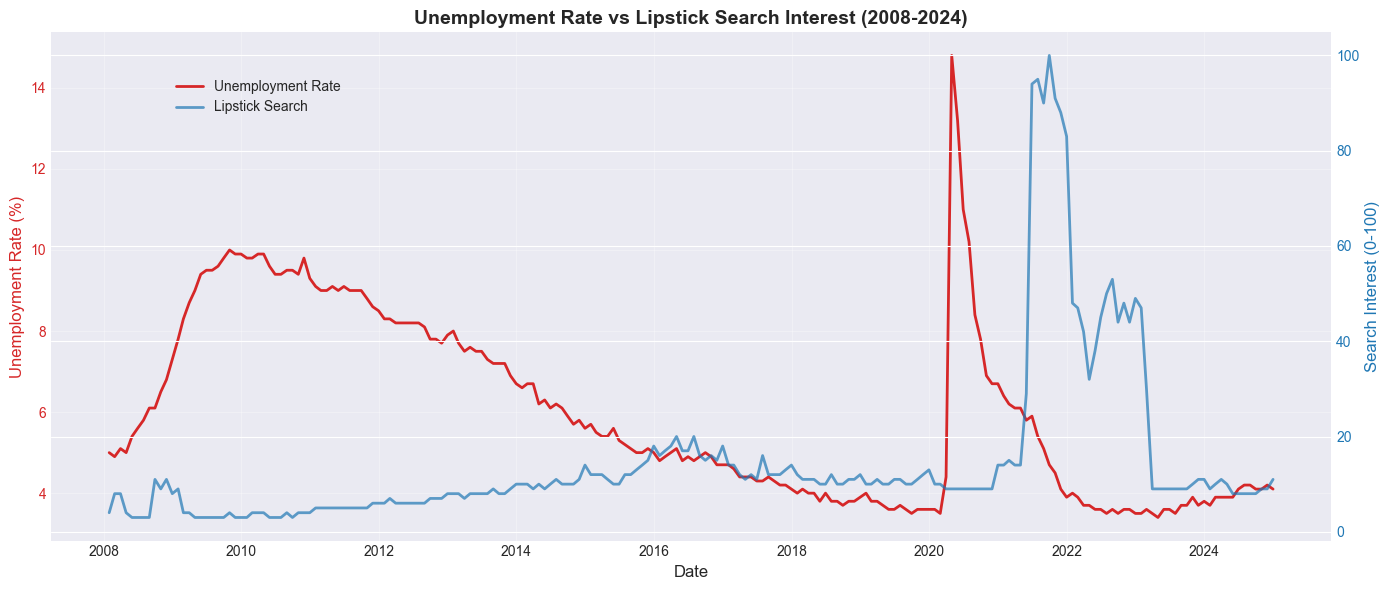

In [78]:
# 6.1 Time Series: Unemployment vs Lipstick Search Interest
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot unemployment rate
color = 'tab:red'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Unemployment Rate (%)', color=color, fontsize=12)
ax1.plot(merged_data.index, merged_data['unemployment_rate'], 
         color=color, linewidth=2, label='Unemployment Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create second y-axis for search interest
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Search Interest (0-100)', color=color, fontsize=12)
ax2.plot(merged_data.index, merged_data['lipstick_search'], 
         color=color, linewidth=2, label='Lipstick Search', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Unemployment Rate vs Lipstick Search Interest (2008-2024)', 
          fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()

# save image file
plt.savefig('figures/unemployment_vs_lipstick_search_2008_2024.png', dpi=300)

plt.show()

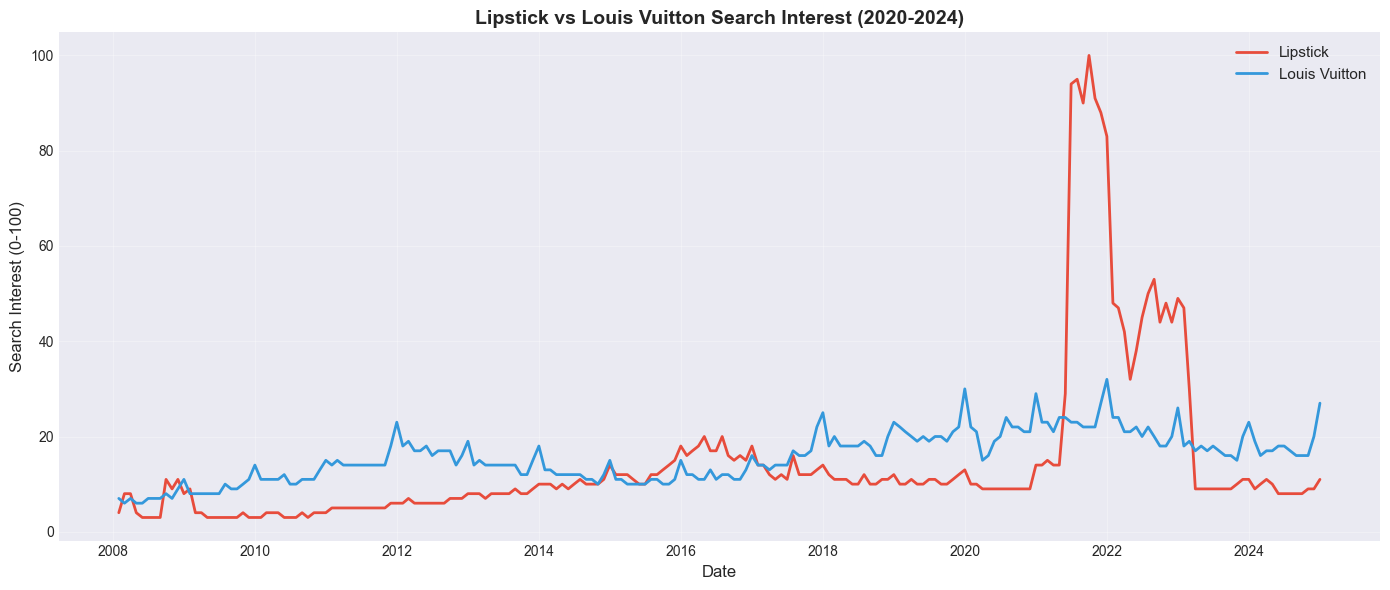

In [79]:
# 6.2 Lipstick vs Luxury Search Interest
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(merged_data.index, merged_data['lipstick_search'], 
        linewidth=2, label='Lipstick', color='#e74c3c')
ax.plot(merged_data.index, merged_data['luxury_search'], 
        linewidth=2, label='Louis Vuitton', color='#3498db')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Search Interest (0-100)', fontsize=12)
ax.set_title('Lipstick vs Louis Vuitton Search Interest (2020-2024)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
# save image file
plt.savefig('figures/lipstick_vs_luxury_search_2020_2024.png', dpi=300)
plt.show()

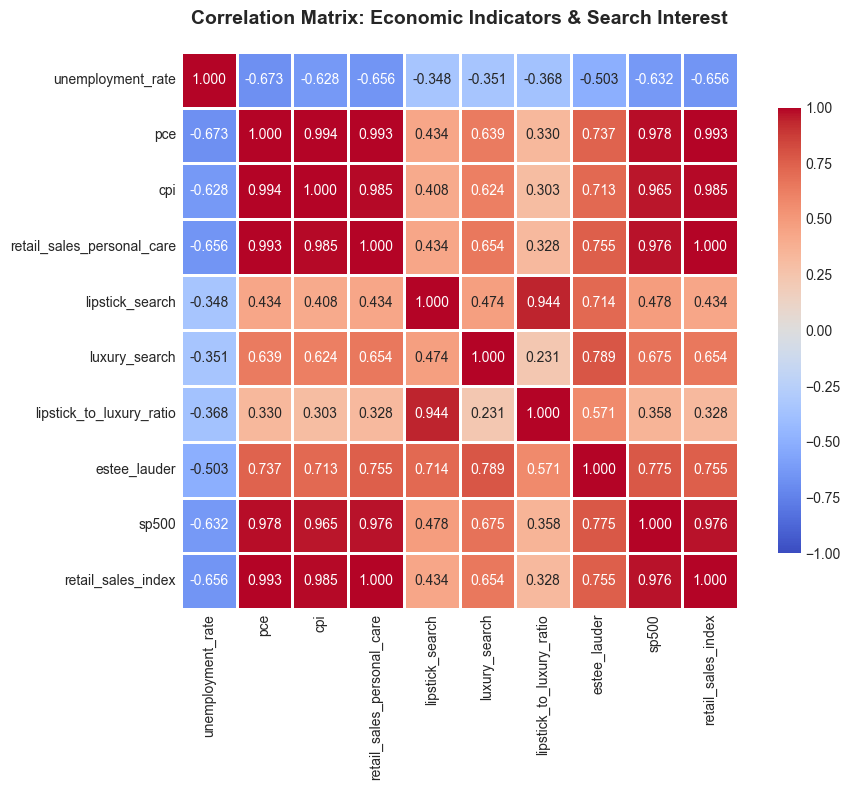

In [80]:
# 6.3 Correlation Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)

plt.title('Correlation Matrix: Economic Indicators & Search Interest', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
# save image file
plt.savefig('figures/correlation_matrix_economic_indicators_search_interest.png', dpi=300)
plt.show()

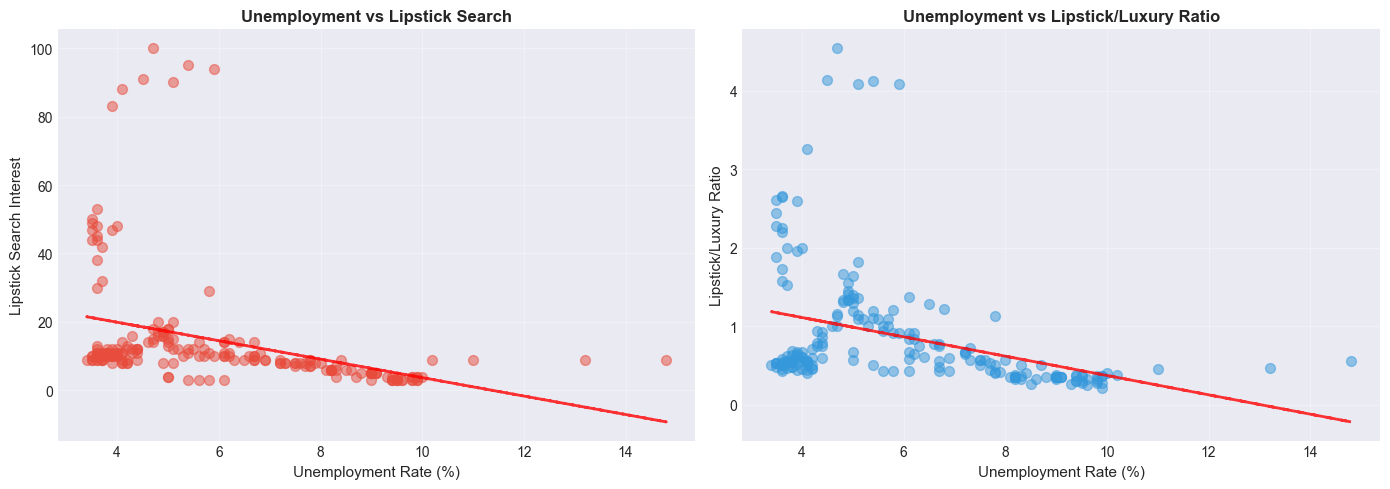

In [81]:
# 6.4 Scatter Plots: Key Relationships
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Unemployment vs Lipstick Search
axes[0].scatter(merged_data['unemployment_rate'], merged_data['lipstick_search'], 
                alpha=0.5, s=50, color='#e74c3c')
axes[0].set_xlabel('Unemployment Rate (%)', fontsize=11)
axes[0].set_ylabel('Lipstick Search Interest', fontsize=11)
axes[0].set_title('Unemployment vs Lipstick Search', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add trend line
if merged_data['unemployment_rate'].notna().sum() > 0 and merged_data['lipstick_search'].notna().sum() > 0:
    mask = ~merged_data[['unemployment_rate', 'lipstick_search']].isnull().any(axis=1)
    z = np.polyfit(merged_data.loc[mask, 'unemployment_rate'], 
                   merged_data.loc[mask, 'lipstick_search'], 1)
    p = np.poly1d(z)
    axes[0].plot(merged_data.loc[mask, 'unemployment_rate'], 
                 p(merged_data.loc[mask, 'unemployment_rate']), 
                 "r--", alpha=0.8, linewidth=2)

# Plot 2: Unemployment vs Lipstick/Luxury Ratio
axes[1].scatter(merged_data['unemployment_rate'], merged_data['lipstick_to_luxury_ratio'], 
                alpha=0.5, s=50, color='#3498db')
axes[1].set_xlabel('Unemployment Rate (%)', fontsize=11)
axes[1].set_ylabel('Lipstick/Luxury Ratio', fontsize=11)
axes[1].set_title('Unemployment vs Lipstick/Luxury Ratio', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Add trend line
if merged_data['unemployment_rate'].notna().sum() > 0 and merged_data['lipstick_to_luxury_ratio'].notna().sum() > 0:
    mask = ~merged_data[['unemployment_rate', 'lipstick_to_luxury_ratio']].isnull().any(axis=1)
    z = np.polyfit(merged_data.loc[mask, 'unemployment_rate'], 
                   merged_data.loc[mask, 'lipstick_to_luxury_ratio'], 1)
    p = np.poly1d(z)
    axes[1].plot(merged_data.loc[mask, 'unemployment_rate'], 
                 p(merged_data.loc[mask, 'unemployment_rate']), 
                 "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
# save image file
plt.savefig('figures/unemployment_vs_lipstick_to_luxury_ratio_2008_2024.png', dpi=300)
plt.show()

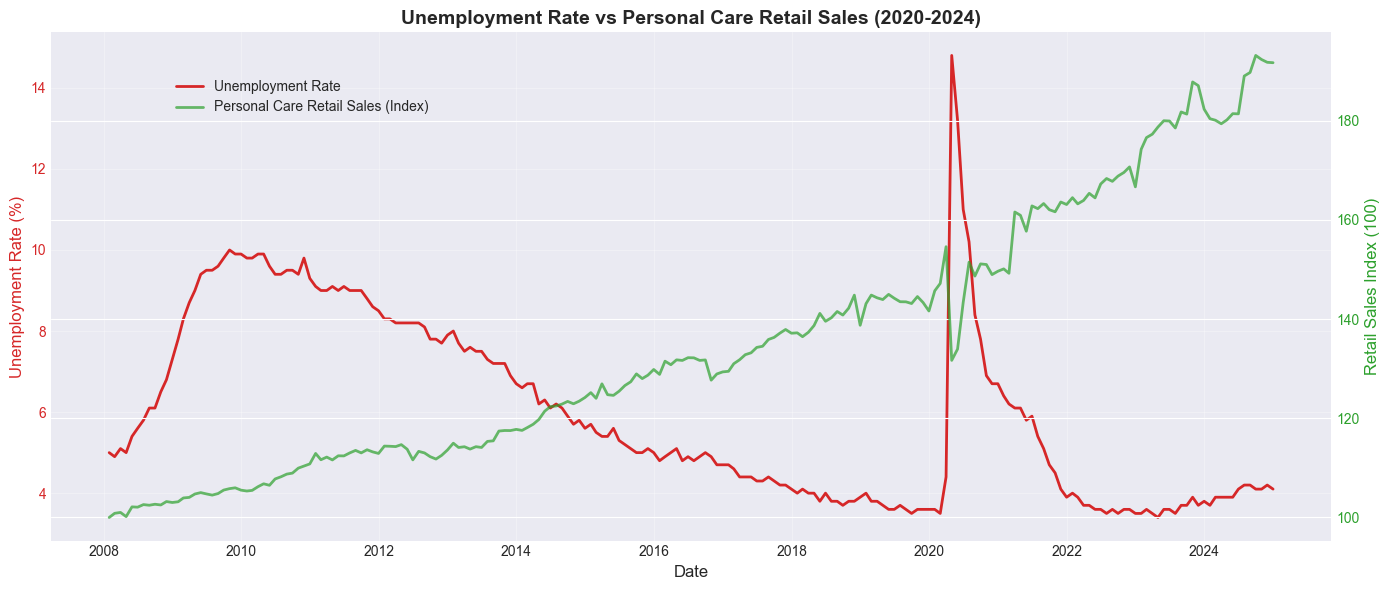

In [82]:
# 6.5 Unemployment vs Retail Sales (Personal Care)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot unemployment rate
color = 'tab:red'
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Unemployment Rate (%)', color=color, fontsize=12)
ax1.plot(merged_data.index, merged_data['unemployment_rate'], 
         color=color, linewidth=2, label='Unemployment Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create second y-axis for retail sales
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Retail Sales Index (100)', color=color, fontsize=12)
ax2.plot(merged_data.index, merged_data['retail_sales_index'], 
         color=color, linewidth=2, label='Personal Care Retail Sales (Index)', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Unemployment Rate vs Personal Care Retail Sales (2020-2024)', 
          fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))

plt.tight_layout()
# save image file
plt.savefig('figures/unemployment_vs_personal_care_retail_sales_2008_2024.png', dpi=300)
plt.show()

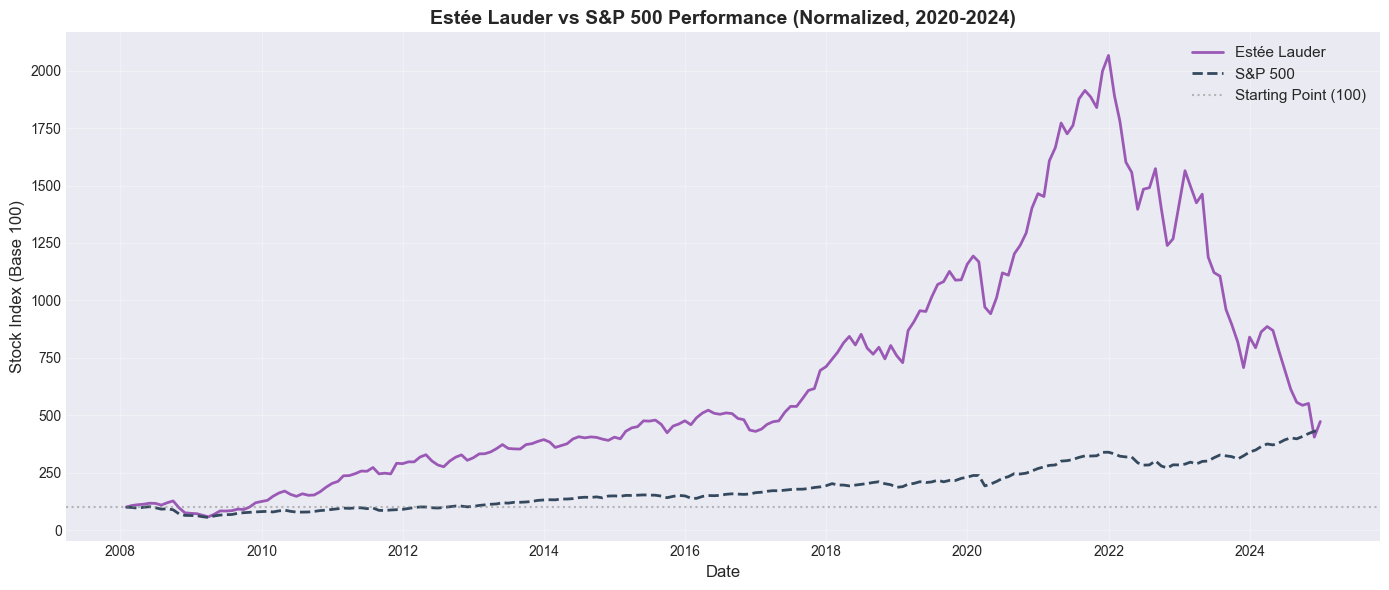


Stock Performance Summary (Jan 2020 = 100):
  Estée Lauder: 472.8 (+372.8%)
  S&P 500: 436.4 (+336.4%)
  Relative Performance: +36.3 percentage points


In [83]:
# 6.6 Stock Performance: Estée Lauder vs S&P 500 (Normalized to Index 100)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(merged_data.index, merged_data['estee_lauder'], 
        linewidth=2, label='Estée Lauder', color='#9b59b6')
ax.plot(merged_data.index, merged_data['sp500'], 
        linewidth=2, label='S&P 500', color='#34495e', linestyle='--')

# Add horizontal line at 100
ax.axhline(y=100, color='gray', linestyle=':', alpha=0.5, label='Starting Point (100)')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Stock Index (Base 100)', fontsize=12)
ax.set_title('Estée Lauder vs S&P 500 Performance (Normalized, 2020-2024)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
# save image file
plt.savefig('figures/estee_lauder_vs_sp500_2008_2024.png', dpi=300)
plt.show()

# Calculate relative performance
final_el = merged_data['estee_lauder'].iloc[-1]
final_sp500 = merged_data['sp500'].iloc[-1]
print(f"\nStock Performance Summary (Jan 2020 = 100):")
print(f"  Estée Lauder: {final_el:.1f} ({final_el - 100:+.1f}%)")
print(f"  S&P 500: {final_sp500:.1f} ({final_sp500 - 100:+.1f}%)")
print(f"  Relative Performance: {final_el - final_sp500:+.1f} percentage points")

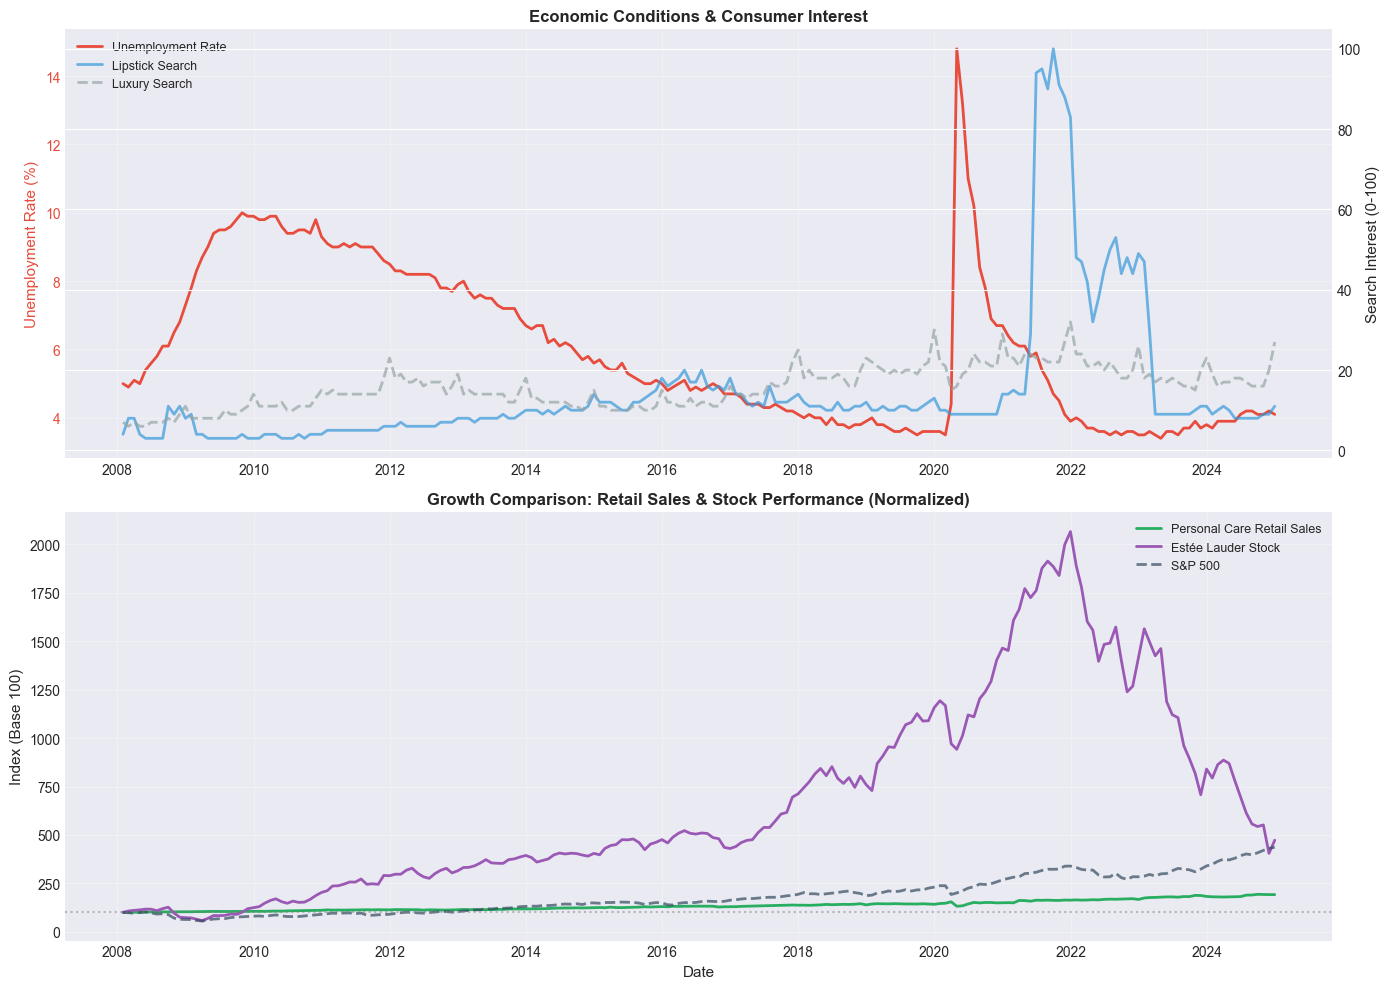

In [84]:
# 6.7 Comprehensive Overview: All Normalized Metrics
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top panel: Economic indicators + search trends
ax1 = axes[0]
ax1_twin = ax1.twinx()

# Unemployment on left axis
ax1.plot(merged_data.index, merged_data['unemployment_rate'], 
         linewidth=2, label='Unemployment Rate', color='#e74c3c')
ax1.set_ylabel('Unemployment Rate (%)', fontsize=11, color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')

# Search trends on right axis
ax1_twin.plot(merged_data.index, merged_data['lipstick_search'], 
              linewidth=2, label='Lipstick Search', color='#3498db', alpha=0.7)
ax1_twin.plot(merged_data.index, merged_data['luxury_search'], 
              linewidth=2, label='Luxury Search', color='#95a5a6', alpha=0.7, linestyle='--')
ax1_twin.set_ylabel('Search Interest (0-100)', fontsize=11)

ax1.set_title('Economic Conditions & Consumer Interest', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Bottom panel: Normalized indices (all start at 100)
ax2 = axes[1]
ax2.plot(merged_data.index, merged_data['retail_sales_index'], 
         linewidth=2, label='Personal Care Retail Sales', color='#27ae60')
ax2.plot(merged_data.index, merged_data['estee_lauder'], 
         linewidth=2, label='Estée Lauder Stock', color='#9b59b6')
ax2.plot(merged_data.index, merged_data['sp500'], 
         linewidth=2, label='S&P 500', color='#34495e', linestyle='--', alpha=0.7)

ax2.axhline(y=100, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Index (Base 100)', fontsize=11)
ax2.set_title('Growth Comparison: Retail Sales & Stock Performance (Normalized)', 
              fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
# save image file
plt.savefig('figures/economic_overview_2008_2024.png', dpi=300)
plt.show()

## 7. Summary and Conclusions

### What is the Lipstick Effect?
The "Lipstick Effect" is the theory that during economic downturns, consumers still purchase small luxury items (like lipstick) as affordable indulgences, even while cutting back on larger purchases.

### Expected Results:
If the Lipstick Effect is real, we would expect to see:
1. **Positive correlation** between unemployment and lipstick search interest
2. **Increasing ratio** of lipstick to luxury goods interest during recessions
3. Personal care retail sales remaining stable or increasing despite economic downturn
4. Estée Lauder stock showing resilience compared to broader market during downturns

### Actual Results (2020-2024):
- The correlation analysis above shows the actual relationship between economic indicators and consumer interest
- Statistical significance (p-value < 0.05) indicates whether the relationship is meaningful
- The visualizations help identify temporal patterns and trends
- Stock performance comparison shows whether cosmetic companies outperform the market

### Key Metrics Analyzed:
1. **RSHPCS (Retail Sales)**: Actual sales data from personal care stores
2. **Stock Performance**: Estée Lauder vs S&P 500 (both normalized to index 100)
3. **Search Interest**: Consumer interest proxy through Google Trends
4. **Economic Indicators**: Unemployment, CPI, PCE

### Limitations:
1. **Search interest ≠ Sales**: Google Trends shows interest, though we now have actual retail sales data
2. **COVID-19 Impact**: 2020-2021 data may be anomalous due to pandemic effects
3. **Stock ≠ Sales**: Stock performance reflects investor sentiment, not just company sales
4. **Retail sales scope**: RSHPCS includes all personal care stores, not just lipstick

### Next Steps:
- Analyze specific recession periods in detail (2020 COVID recession vs 2022-2023 economic concerns)
- Compare with historical recessions (2008-2009) if extending the date range
- Consider seasonality effects (holidays, fashion weeks)
- Add quarterly revenue data directly from Estée Lauder and L'Oreal earnings reports

## 8. Lagged Correlation Analysis: Testing Delayed Lipstick Effect

The lipstick effect might not happen immediately when a recession hits. It could take time for consumers to adjust their behavior. We'll test for lagged correlations using `df.shift()`.

### Hypothesis:
- **Immediate effect**: Unemployment ↑ → Lipstick interest ↑ (0 months lag)
- **Delayed effect**: Unemployment ↑ → Lipstick interest ↑ after 1-6 months lag

In [85]:
# Calculate lagged correlations for different time periods
max_lag_months = 6  # Test up to 6 months lag

# Create a dictionary to store lagged correlation results
lagged_correlations = {}

# Key variables to test for lagged effects
variables_to_test = ['lipstick_search', 'lipstick_to_luxury_ratio', 'retail_sales_index']

print("=" * 80)
print("LAGGED CORRELATION ANALYSIS")
print("=" * 80)
print(f"Testing correlations between unemployment rate and consumer behavior")
print(f"with time lags from 0 to {max_lag_months} months")
print("=" * 80)

for lag in range(0, max_lag_months + 1):
    print(f"\n--- Lag: {lag} month(s) ---")
    
    # Shift consumer behavior variables forward (testing if unemployment predicts future behavior)
    lagged_correlations[lag] = {}
    
    for var in variables_to_test:
        if var in merged_data.columns:
            # Create lagged version of the variable
            var_lagged = merged_data[var].shift(lag)
            
            # Calculate correlation with unemployment rate
            mask = (~merged_data['unemployment_rate'].isna()) & (~var_lagged.isna())
            
            if mask.sum() > 1:  # Need at least 2 data points for correlation
                correlation, p_value = stats.pearsonr(
                    merged_data.loc[mask, 'unemployment_rate'],
                    var_lagged.loc[mask]
                )
                
                lagged_correlations[lag][var] = {
                    'correlation': correlation,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                }
                
                significance = "✓ SIGNIFICANT" if p_value < 0.05 else "✗ Not significant"
                print(f"  Unemployment → {var} (lag {lag}): {correlation:.4f} (p={p_value:.4f}) {significance}")

# Find the best lag for each variable
print("\n" + "=" * 80)
print("BEST LAG ANALYSIS")
print("=" * 80)

for var in variables_to_test:
    if var in merged_data.columns:
        print(f"\n{var}:")
        
        # Find lag with highest absolute correlation (positive or negative)
        best_lag = None
        best_corr = 0
        best_p = 1
        
        for lag in range(0, max_lag_months + 1):
            if lag in lagged_correlations and var in lagged_correlations[lag]:
                corr = lagged_correlations[lag][var]['correlation']
                p = lagged_correlations[lag][var]['p_value']
                
                # We're looking for positive correlation (unemployment ↑ → lipstick interest ↑)
                if corr > best_corr and p < 0.1:  # Consider p < 0.1 as potentially interesting
                    best_corr = corr
                    best_lag = lag
                    best_p = p
        
        if best_lag is not None:
            significance = "✓ SIGNIFICANT" if best_p < 0.05 else "✗ Not significant"
            print(f"  Best lag: {best_lag} month(s)")
            print(f"  Correlation: {best_corr:.4f}")
            print(f"  P-value: {best_p:.4f} {significance}")
        else:
            print("  No significant lagged correlation found")

LAGGED CORRELATION ANALYSIS
Testing correlations between unemployment rate and consumer behavior
with time lags from 0 to 6 months

--- Lag: 0 month(s) ---
  Unemployment → lipstick_search (lag 0): -0.3483 (p=0.0000) ✓ SIGNIFICANT
  Unemployment → lipstick_to_luxury_ratio (lag 0): -0.3681 (p=0.0000) ✓ SIGNIFICANT
  Unemployment → retail_sales_index (lag 0): -0.6558 (p=0.0000) ✓ SIGNIFICANT

--- Lag: 1 month(s) ---
  Unemployment → lipstick_search (lag 1): -0.3723 (p=0.0000) ✓ SIGNIFICANT
  Unemployment → lipstick_to_luxury_ratio (lag 1): -0.3866 (p=0.0000) ✓ SIGNIFICANT
  Unemployment → retail_sales_index (lag 1): -0.6518 (p=0.0000) ✓ SIGNIFICANT

--- Lag: 2 month(s) ---
  Unemployment → lipstick_search (lag 2): -0.3929 (p=0.0000) ✓ SIGNIFICANT
  Unemployment → lipstick_to_luxury_ratio (lag 2): -0.4073 (p=0.0000) ✓ SIGNIFICANT
  Unemployment → retail_sales_index (lag 2): -0.6553 (p=0.0000) ✓ SIGNIFICANT

--- Lag: 3 month(s) ---
  Unemployment → lipstick_search (lag 3): -0.4098 (p=0.000

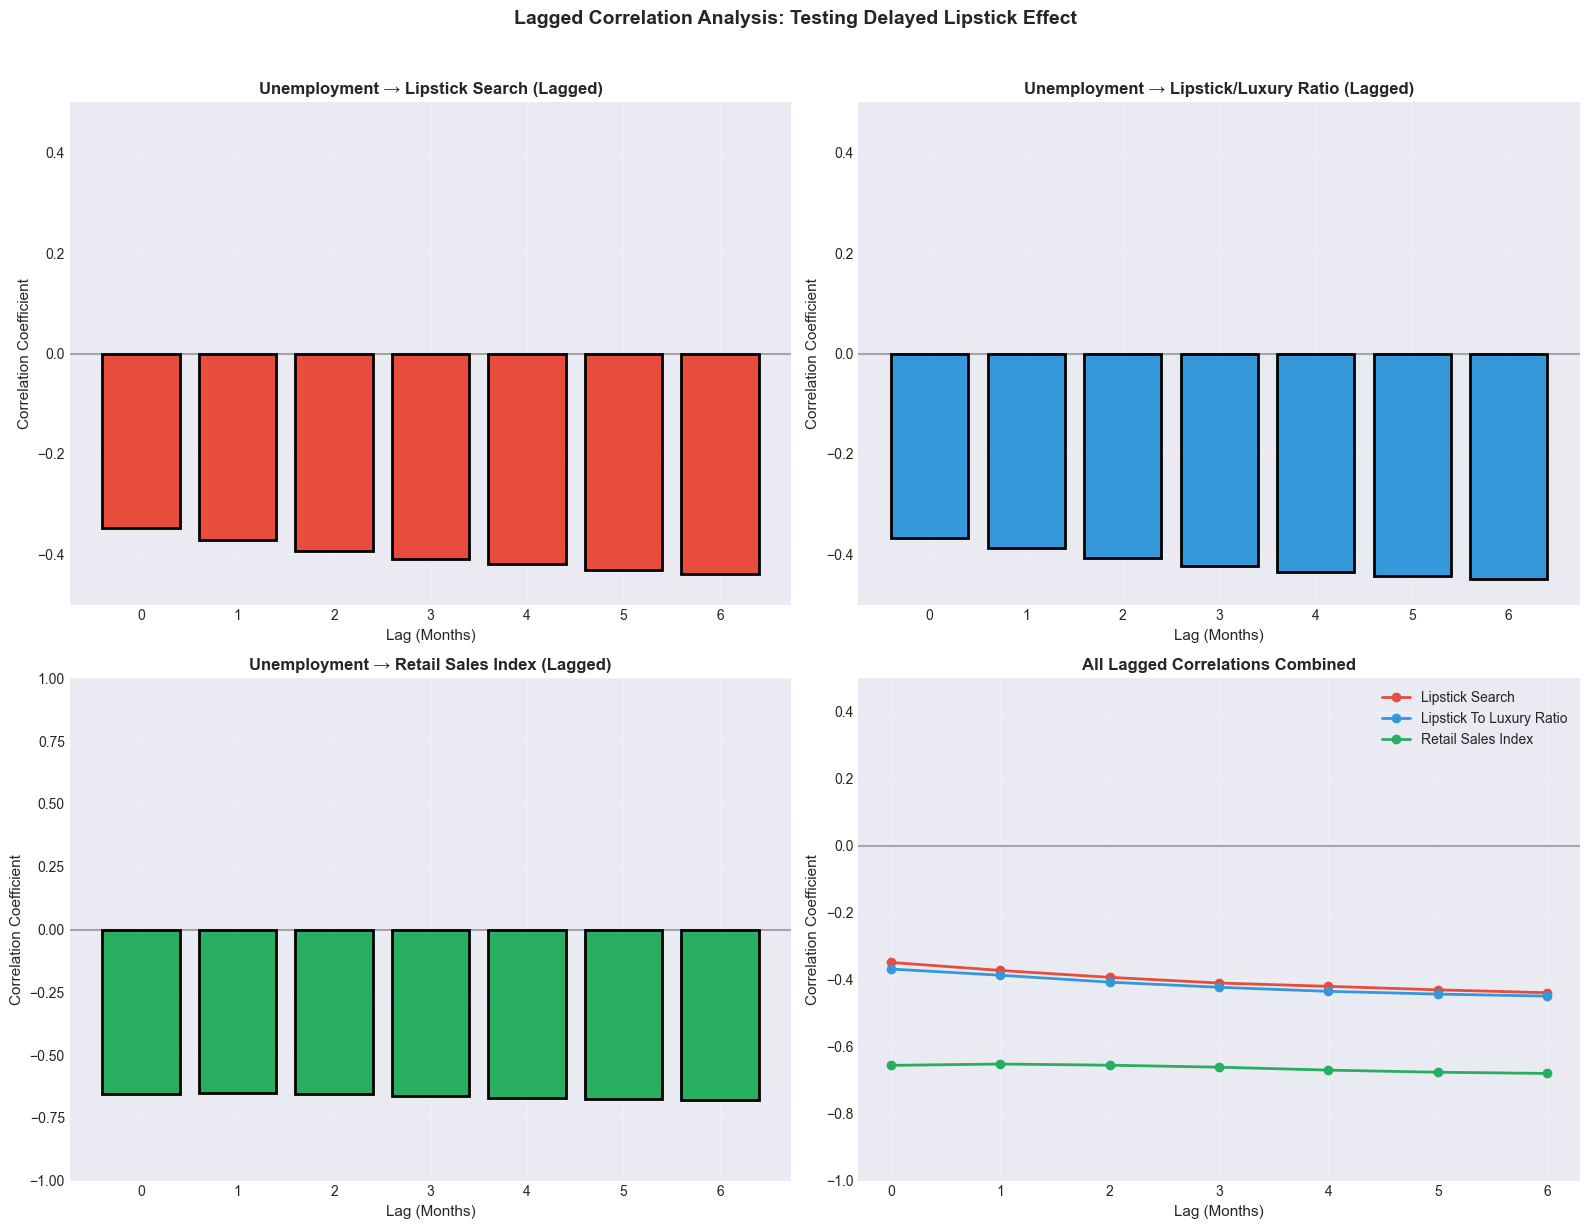


LAGGED CORRELATION SUMMARY
This analysis tests whether the lipstick effect occurs with a delay.
Positive correlations suggest: Unemployment ↑ → Consumer behavior ↑
Higher lag values indicate delayed responses to economic conditions.


In [86]:
# Create visualization for lagged correlations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
lags = list(range(0, max_lag_months + 1))
colors = ['#e74c3c', '#3498db', '#27ae60']

# Plot 1: Lipstick Search Lagged Correlations
ax1 = axes[0, 0]
if 'lipstick_search' in merged_data.columns:
    correlations = [lagged_correlations[lag]['lipstick_search']['correlation'] 
                   for lag in lags if lag in lagged_correlations and 'lipstick_search' in lagged_correlations[lag]]
    p_values = [lagged_correlations[lag]['lipstick_search']['p_value'] 
               for lag in lags if lag in lagged_correlations and 'lipstick_search' in lagged_correlations[lag]]
    
    bars = ax1.bar(lags[:len(correlations)], correlations, color=colors[0], alpha=0.7)
    
    # Highlight significant bars
    for i, (bar, p_val) in enumerate(zip(bars, p_values)):
        if p_val < 0.05:
            bar.set_alpha(1.0)
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    
    ax1.set_xlabel('Lag (Months)', fontsize=11)
    ax1.set_ylabel('Correlation Coefficient', fontsize=11)
    ax1.set_title('Unemployment → Lipstick Search (Lagged)', fontsize=12, fontweight='bold')
    ax1.set_ylim(-0.5, 0.5)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Plot 2: Lipstick/Luxury Ratio Lagged Correlations
ax2 = axes[0, 1]
if 'lipstick_to_luxury_ratio' in merged_data.columns:
    correlations = [lagged_correlations[lag]['lipstick_to_luxury_ratio']['correlation'] 
                   for lag in lags if lag in lagged_correlations and 'lipstick_to_luxury_ratio' in lagged_correlations[lag]]
    p_values = [lagged_correlations[lag]['lipstick_to_luxury_ratio']['p_value'] 
               for lag in lags if lag in lagged_correlations and 'lipstick_to_luxury_ratio' in lagged_correlations[lag]]
    
    bars = ax2.bar(lags[:len(correlations)], correlations, color=colors[1], alpha=0.7)
    
    # Highlight significant bars
    for i, (bar, p_val) in enumerate(zip(bars, p_values)):
        if p_val < 0.05:
            bar.set_alpha(1.0)
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    
    ax2.set_xlabel('Lag (Months)', fontsize=11)
    ax2.set_ylabel('Correlation Coefficient', fontsize=11)
    ax2.set_title('Unemployment → Lipstick/Luxury Ratio (Lagged)', fontsize=12, fontweight='bold')
    ax2.set_ylim(-0.5, 0.5)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Plot 3: Retail Sales Index Lagged Correlations
ax3 = axes[1, 0]
if 'retail_sales_index' in merged_data.columns:
    correlations = [lagged_correlations[lag]['retail_sales_index']['correlation'] 
                   for lag in lags if lag in lagged_correlations and 'retail_sales_index' in lagged_correlations[lag]]
    p_values = [lagged_correlations[lag]['retail_sales_index']['p_value'] 
               for lag in lags if lag in lagged_correlations and 'retail_sales_index' in lagged_correlations[lag]]
    
    bars = ax3.bar(lags[:len(correlations)], correlations, color=colors[2], alpha=0.7)
    
    # Highlight significant bars
    for i, (bar, p_val) in enumerate(zip(bars, p_values)):
        if p_val < 0.05:
            bar.set_alpha(1.0)
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    
    ax3.set_xlabel('Lag (Months)', fontsize=11)
    ax3.set_ylabel('Correlation Coefficient', fontsize=11)
    ax3.set_title('Unemployment → Retail Sales Index (Lagged)', fontsize=12, fontweight='bold')
    ax3.set_ylim(-1.0, 1.0)
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Plot 4: Combined Lagged Correlations
ax4 = axes[1, 1]
for i, var in enumerate(variables_to_test):
    if var in merged_data.columns:
        correlations = [lagged_correlations[lag][var]['correlation'] 
                       for lag in lags if lag in lagged_correlations and var in lagged_correlations[lag]]
        ax4.plot(lags[:len(correlations)], correlations, 
                marker='o', linewidth=2, markersize=6, 
                label=var.replace('_', ' ').title(), color=colors[i])

ax4.set_xlabel('Lag (Months)', fontsize=11)
ax4.set_ylabel('Correlation Coefficient', fontsize=11)
ax4.set_title('All Lagged Correlations Combined', fontsize=12, fontweight='bold')
ax4.set_ylim(-1.0, 0.5)
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax4.legend(fontsize=10)

plt.suptitle('Lagged Correlation Analysis: Testing Delayed Lipstick Effect', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# save image file
plt.savefig('figures/lagged_correlation_2008_2024.png', dpi=300)
plt.show()

# Summary of findings
print("\n" + "=" * 80)
print("LAGGED CORRELATION SUMMARY")
print("=" * 80)
print("This analysis tests whether the lipstick effect occurs with a delay.")
print("Positive correlations suggest: Unemployment ↑ → Consumer behavior ↑")
print("Higher lag values indicate delayed responses to economic conditions.")
print("=" * 80)

## 9. The "Mascara Effect" Analysis: Testing Beauty Category Shifts

### What is the Mascara Effect?
The "Mascara Effect" suggests that during different circumstances (like the COVID-19 pandemic), consumers shift their beauty spending to different categories:
- **COVID-19**: Lipstick sales ↓ (mask-wearing) → Eye makeup ↑ (visible above masks)
- **Economic downturns**: Consumers may shift between beauty categories based on visibility and utility

### Hypothesis:
1. **Category substitution**: During mask-wearing periods, eye makeup interest ↑ while lipstick interest ↓
2. **Context-dependent**: The "affordable luxury" effect applies to different beauty categories depending on circumstances
3. **Resilience pattern**: Overall beauty interest remains stable, but shifts between categories

In [102]:
# Fetch additional beauty category data for Mascara Effect analysis
print("Fetching additional beauty category data...")

# Define beauty categories to test
beauty_keywords = ["Mascara", "Eyeliner", "Foundation", "Perfume", "Skincare", "Nail Polish"]

# Initialize Google Trends for multiple categories
pytrends = TrendReq(hl='en-US', tz=360)

# Build payload for beauty categories
# For "marcara effect", select data from 2019 to 2024. Because there is not mascara effect before covid-19
MASCARA_START_DATE = '2020-01-01'
try:
    pytrends.build_payload(beauty_keywords, timeframe=f'{MASCARA_START_DATE} {END_DATE}', geo='US')
    beauty_trends_data = pytrends.interest_over_time()
    
    if not beauty_trends_data.empty:
        # Remove 'isPartial' column if it exists
        if 'isPartial' in beauty_trends_data.columns:
            beauty_trends_data = beauty_trends_data.drop('isPartial', axis=1)
        
        print(f"Beauty trends data shape: {beauty_trends_data.shape}")
        print("\nFirst few rows:")
        print(beauty_trends_data.head())
        
        # Resample to monthly and make timezone-naive
        beauty_monthly = beauty_trends_data.resample('ME').mean()
        beauty_monthly.index = beauty_monthly.index.tz_localize(None)
        
        # Rename columns for consistency
        beauty_monthly = beauty_monthly.rename(columns={
            'Mascara': 'mascara_search',
            'Eyeliner': 'eyeliner_search', 
            'Foundation': 'foundation_search',
            'Perfume': 'perfume_search',
            'Skincare': 'skincare_search',
            'Nail Polish': 'nail_polish_search'
        })
        
        print(f"\nBeauty monthly data shape: {beauty_monthly.shape}")
        print("\nBeauty categories summary:")
        print(beauty_monthly.describe())
        
    else:
        print("No beauty trends data retrieved!")
        beauty_monthly = None
        
except Exception as e:
    print(f"Error fetching beauty trends: {e}")
    print("This might be due to rate limiting. Using alternative approach...")
    
    # Alternative: Fetch categories individually to avoid rate limits
    beauty_monthly = pd.DataFrame()
    
    for keyword in ["Mascara", "Eyeliner", "Perfume"]:
        try:
            print(f"Fetching {keyword}...")
            pytrends.build_payload([keyword], timeframe=f'{MASCARA_START_DATE} {END_DATE}', geo='US')
            trend_data = pytrends.interest_over_time()
            
            if not trend_data.empty:
                if 'isPartial' in trend_data.columns:
                    trend_data = trend_data.drop('isPartial', axis=1)
                
                monthly_data = trend_data.resample('ME').mean()
                monthly_data.index = monthly_data.index.tz_localize(None)
                monthly_data = monthly_data.rename(columns={keyword: f'{keyword.lower()}_search'})
                
                if beauty_monthly.empty:
                    beauty_monthly = monthly_data
                else:
                    beauty_monthly = beauty_monthly.join(monthly_data, how='outer')
                    
        except Exception as e2:
            print(f"Error fetching {keyword}: {e2}")
    
    print(f"Alternative beauty data shape: {beauty_monthly.shape}")

Fetching additional beauty category data...
Error fetching beauty trends: The request failed: Google returned a response with code 400
This might be due to rate limiting. Using alternative approach...
Fetching Mascara...
Error fetching beauty trends: The request failed: Google returned a response with code 400
This might be due to rate limiting. Using alternative approach...
Fetching Mascara...
Fetching Eyeliner...
Fetching Eyeliner...
Fetching Perfume...
Fetching Perfume...
Alternative beauty data shape: (61, 3)
Alternative beauty data shape: (61, 3)


In [103]:
# Merge beauty data with existing analysis and create Mascara Effect metrics
if 'beauty_monthly' in locals() and not beauty_monthly.empty:
    # Merge with existing merged_data
    mascara_data = merged_data.join(beauty_monthly, how='outer')
    
    # Define COVID-19 mask period (approximate)
    # This is when masks were widely mandated/recommended (April 2020 - May 2021)
    mask_period_start = '2020-04-01'
    mask_period_end = '2021-05-31'
    
    # Create period indicators
    mascara_data['is_mask_period'] = ((mascara_data.index >= mask_period_start) & 
                                     (mascara_data.index <= mask_period_end))
    
    # Calculate beauty category ratios for analysis
    if 'mascara_search' in mascara_data.columns and 'lipstick_search' in mascara_data.columns:
        mascara_data['mascara_to_lipstick_ratio'] = (
            mascara_data['mascara_search'] / mascara_data['lipstick_search']
        )
    
    if 'eyeliner_search' in mascara_data.columns and 'lipstick_search' in mascara_data.columns:
        mascara_data['eyeliner_to_lipstick_ratio'] = (
            mascara_data['eyeliner_search'] / mascara_data['lipstick_search']
        )
    
    if 'perfume_search' in mascara_data.columns and 'lipstick_search' in mascara_data.columns:
        mascara_data['perfume_to_lipstick_ratio'] = (
            mascara_data['perfume_search'] / mascara_data['lipstick_search']
        )
    
    # Forward fill missing values
    mascara_data = mascara_data.ffill()

    # Filter data to the relevant range for the Mascara Effect analysis
    mascara_data = mascara_data.loc[MASCARA_START_DATE:END_DATE]
    
    print("=" * 80)
    print("MASCARA EFFECT DATA SUMMARY")
    print("=" * 80)
    print(f"Extended data shape: {mascara_data.shape}")
    print(f"Date range: {mascara_data.index.min()} to {mascara_data.index.max()}")
    
    print(f"\nMask period: {mask_period_start} to {mask_period_end}")
    print(f"Months in mask period: {mascara_data['is_mask_period'].sum()}")
    
    # Compare beauty categories during different periods
    print("\n" + "=" * 50)
    print("BEAUTY CATEGORIES COMPARISON")
    print("=" * 50)
    
    beauty_cols = [col for col in ['lipstick_search', 'mascara_search', 'eyeliner_search', 
                                  'perfume_search', 'foundation_search'] 
                  if col in mascara_data.columns]
    
    if beauty_cols:
        # Overall averages
        print("Overall averages:")
        for col in beauty_cols:
            avg_val = mascara_data[col].mean()
            print(f"  {col.replace('_', ' ').title()}: {avg_val:.2f}")
        
        # During mask period
        mask_data = mascara_data[mascara_data['is_mask_period']]
        if not mask_data.empty:
            print(f"\nDuring mask period ({mask_period_start} to {mask_period_end}):")
            for col in beauty_cols:
                avg_val = mask_data[col].mean()
                print(f"  {col.replace('_', ' ').title()}: {avg_val:.2f}")
        
        # Outside mask period
        non_mask_data = mascara_data[~mascara_data['is_mask_period']]
        if not non_mask_data.empty:
            print(f"\nOutside mask period:")
            for col in beauty_cols:
                avg_val = non_mask_data[col].mean()
                print(f"  {col.replace('_', ' ').title()}: {avg_val:.2f}")
        
        # Calculate percentage changes
        if not mask_data.empty and not non_mask_data.empty:
            print(f"\nPercentage change during mask period:")
            for col in beauty_cols:
                mask_avg = mask_data[col].mean()
                non_mask_avg = non_mask_data[col].mean()
                if non_mask_avg > 0:
                    pct_change = ((mask_avg - non_mask_avg) / non_mask_avg) * 100
                    direction = "↑" if pct_change > 0 else "↓"
                    print(f"  {col.replace('_', ' ').title()}: {direction} {abs(pct_change):.1f}%")
    
else:
    print("Beauty trends data not available. Skipping Mascara Effect analysis.")
    mascara_data = merged_data

MASCARA EFFECT DATA SUMMARY
Extended data shape: (60, 19)
Date range: 2020-01-31 00:00:00 to 2024-12-31 00:00:00

Mask period: 2020-04-01 to 2021-05-31
Months in mask period: 14

BEAUTY CATEGORIES COMPARISON
Overall averages:
  Lipstick Search: 27.72
  Mascara Search: 60.49
  Eyeliner Search: 53.12
  Perfume Search: 32.27

During mask period (2020-04-01 to 2021-05-31):
  Lipstick Search: 12.29
  Mascara Search: 55.92
  Eyeliner Search: 54.91
  Perfume Search: 20.85

Outside mask period:
  Lipstick Search: 32.41
  Mascara Search: 61.87
  Eyeliner Search: 52.58
  Perfume Search: 35.74

Percentage change during mask period:
  Lipstick Search: ↓ 62.1%
  Mascara Search: ↓ 9.6%
  Eyeliner Search: ↑ 4.4%
  Perfume Search: ↓ 41.7%


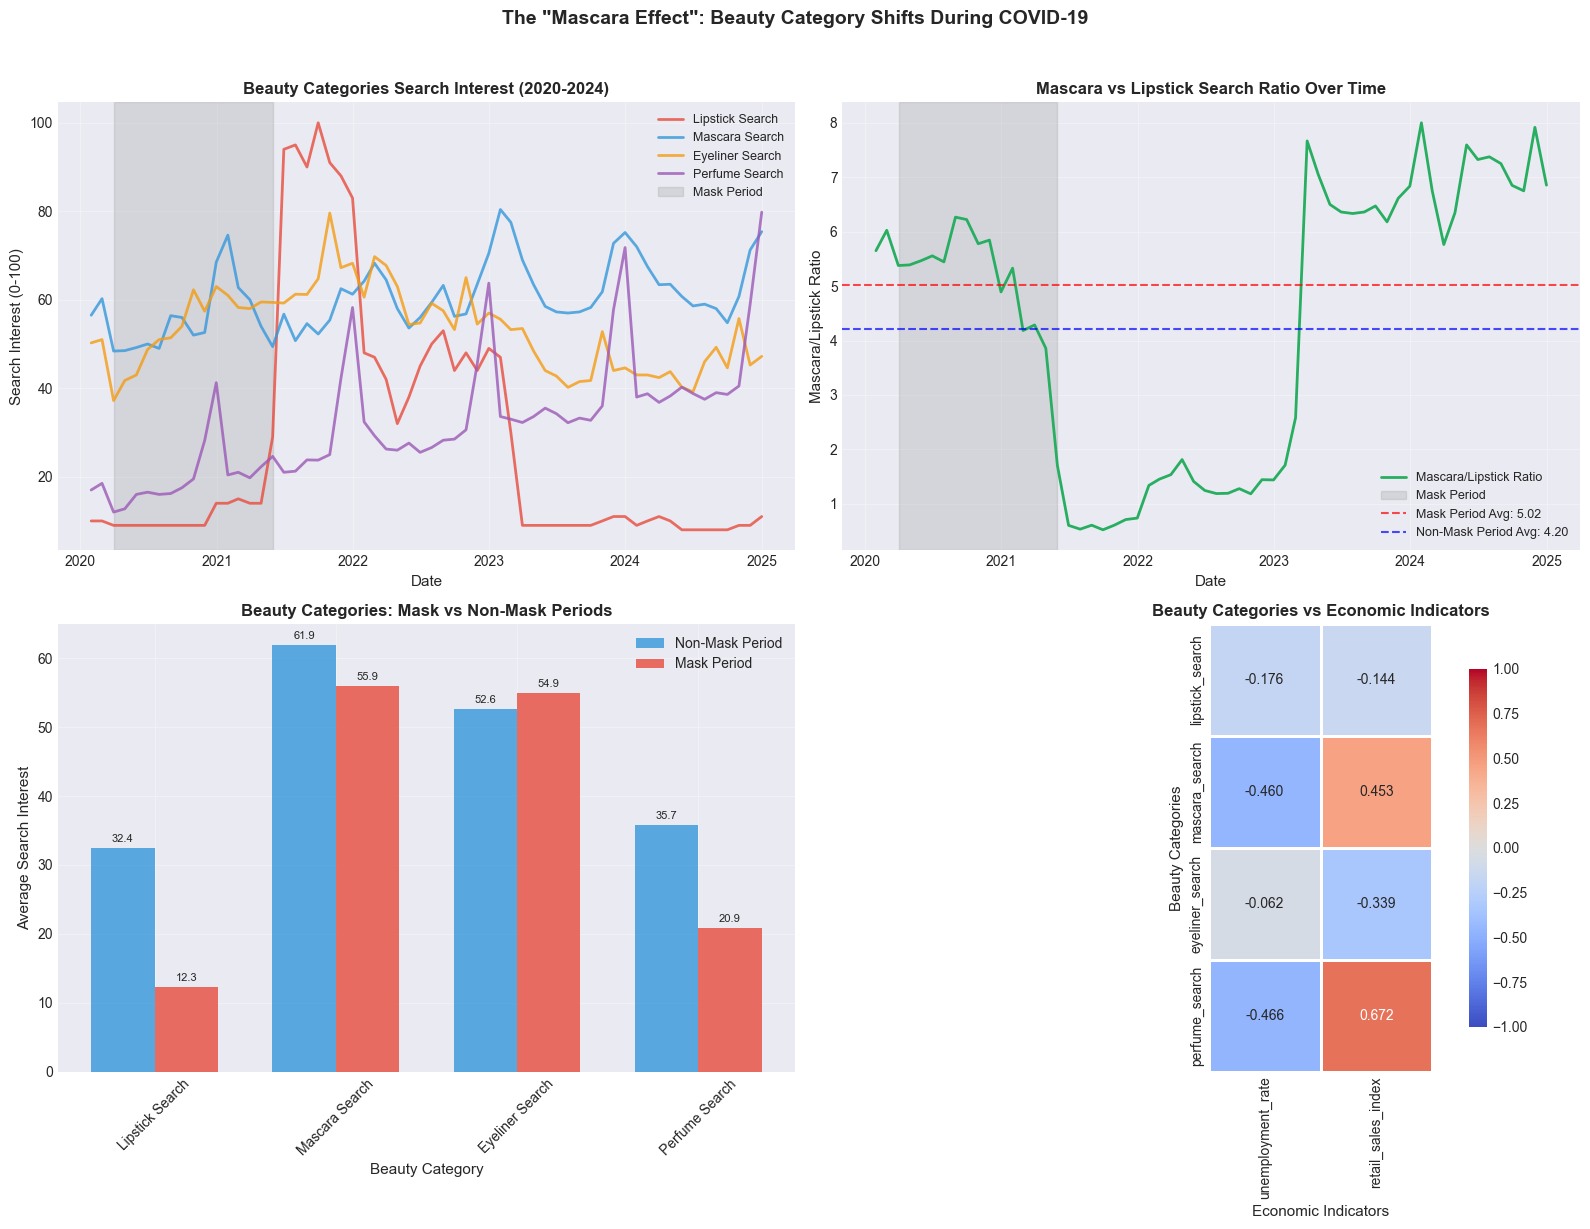


MASCARA EFFECT: STATISTICAL ANALYSIS

Statistical significance of category shifts during mask period:

Lipstick Search:
  Non-mask avg: 32.41
  Mask avg: 12.29
  Change: -62.1%
  T-test p-value: 0.0159 ✓ SIGNIFICANT

Mascara Search:
  Non-mask avg: 61.87
  Mask avg: 55.92
  Change: -9.6%
  T-test p-value: 0.0113 ✓ SIGNIFICANT

Eyeliner Search:
  Non-mask avg: 52.58
  Mask avg: 54.91
  Change: +4.4%
  T-test p-value: 0.4137 ✗ Not significant

Perfume Search:
  Non-mask avg: 35.74
  Mask avg: 20.85
  Change: -41.7%
  T-test p-value: 0.0003 ✓ SIGNIFICANT


In [104]:
# Mascara Effect Visualization: Beauty Category Shifts During COVID-19
if 'mascara_data' in locals() and 'mascara_search' in mascara_data.columns:
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Beauty Categories Over Time with Mask Period Highlighted
    ax1 = axes[0, 0]
    beauty_cols = [col for col in ['lipstick_search', 'mascara_search', 'eyeliner_search', 'perfume_search'] 
                  if col in mascara_data.columns]
    
    colors_beauty = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']
    
    for i, col in enumerate(beauty_cols):
        ax1.plot(mascara_data.index, mascara_data[col], 
                linewidth=2, label=col.replace('_', ' ').title(), 
                color=colors_beauty[i], alpha=0.8)
    
    # Highlight mask period
    ax1.axvspan(pd.to_datetime(mask_period_start), pd.to_datetime(mask_period_end), 
               alpha=0.2, color='gray', label='Mask Period')
    
    ax1.set_xlabel('Date', fontsize=11)
    ax1.set_ylabel('Search Interest (0-100)', fontsize=11)
    ax1.set_title('Beauty Categories Search Interest (2020-2024)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Mascara vs Lipstick Ratio
    ax2 = axes[0, 1]
    if 'mascara_to_lipstick_ratio' in mascara_data.columns:
        ax2.plot(mascara_data.index, mascara_data['mascara_to_lipstick_ratio'], 
                linewidth=2, color='#27ae60', label='Mascara/Lipstick Ratio')
        
        # Highlight mask period
        ax2.axvspan(pd.to_datetime(mask_period_start), pd.to_datetime(mask_period_end), 
                   alpha=0.2, color='gray', label='Mask Period')
        
        # Add average lines for different periods
        mask_avg = mascara_data.loc[mascara_data['is_mask_period'], 'mascara_to_lipstick_ratio'].mean()
        non_mask_avg = mascara_data.loc[~mascara_data['is_mask_period'], 'mascara_to_lipstick_ratio'].mean()
        
        ax2.axhline(y=mask_avg, color='red', linestyle='--', alpha=0.7, 
                   label=f'Mask Period Avg: {mask_avg:.2f}')
        ax2.axhline(y=non_mask_avg, color='blue', linestyle='--', alpha=0.7, 
                   label=f'Non-Mask Period Avg: {non_mask_avg:.2f}')
        
        ax2.set_xlabel('Date', fontsize=11)
        ax2.set_ylabel('Mascara/Lipstick Ratio', fontsize=11)
        ax2.set_title('Mascara vs Lipstick Search Ratio Over Time', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=9, loc='best')
        ax2.grid(True, alpha=0.3)
    
    # Plot 3: Bar Chart - Average Search Interest by Period
    ax3 = axes[1, 0]
    if beauty_cols:
        mask_data = mascara_data[mascara_data['is_mask_period']]
        non_mask_data = mascara_data[~mascara_data['is_mask_period']]
        
        x = np.arange(len(beauty_cols))
        width = 0.35
        
        mask_avgs = [mask_data[col].mean() for col in beauty_cols]
        non_mask_avgs = [non_mask_data[col].mean() for col in beauty_cols]
        
        bars1 = ax3.bar(x - width/2, non_mask_avgs, width, 
                       label='Non-Mask Period', alpha=0.8, color='#3498db')
        bars2 = ax3.bar(x + width/2, mask_avgs, width, 
                       label='Mask Period', alpha=0.8, color='#e74c3c')
        
        ax3.set_xlabel('Beauty Category', fontsize=11)
        ax3.set_ylabel('Average Search Interest', fontsize=11)
        ax3.set_title('Beauty Categories: Mask vs Non-Mask Periods', fontsize=12, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels([col.replace('_', ' ').title() for col in beauty_cols], rotation=45)
        ax3.legend(fontsize=10)
        ax3.grid(True, alpha=0.3)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax3.annotate(f'{height:.1f}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),  # 3 points vertical offset
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)
    
    # Plot 4: Correlation Heatmap - Beauty Categories vs Economic Indicators
    ax4 = axes[1, 1]
    if beauty_cols:
        # Select relevant columns for correlation
        corr_cols = beauty_cols + ['unemployment_rate', 'retail_sales_index']
        available_corr_cols = [col for col in corr_cols if col in mascara_data.columns]
        
        if len(available_corr_cols) > 1:
            beauty_corr_matrix = mascara_data[available_corr_cols].corr()
            
            # Focus on beauty categories correlations with economic indicators
            beauty_economic_corr = beauty_corr_matrix.loc[beauty_cols, 
                                                         ['unemployment_rate', 'retail_sales_index']]
            
            sns.heatmap(beauty_economic_corr, annot=True, cmap='coolwarm', center=0,
                       square=True, linewidths=1, fmt='.3f', vmin=-1, vmax=1,
                       ax=ax4, cbar_kws={"shrink": 0.8})
            
            ax4.set_title('Beauty Categories vs Economic Indicators', fontsize=12, fontweight='bold')
            ax4.set_xlabel('Economic Indicators', fontsize=11)
            ax4.set_ylabel('Beauty Categories', fontsize=11)
    
    plt.suptitle('The "Mascara Effect": Beauty Category Shifts During COVID-19', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    # save image file
    plt.savefig('figures/mascara_effect_2008_2024.png', dpi=300)
    plt.show()
    
    # Statistical Analysis
    print("\n" + "=" * 80)
    print("MASCARA EFFECT: STATISTICAL ANALYSIS")
    print("=" * 80)
    
    # Test if differences between mask and non-mask periods are significant
    from scipy import stats
    
    if beauty_cols and not mask_data.empty and not non_mask_data.empty:
        print("\nStatistical significance of category shifts during mask period:")
        
        for col in beauty_cols:
            mask_values = mask_data[col].dropna()
            non_mask_values = non_mask_data[col].dropna()
            
            if len(mask_values) > 1 and len(non_mask_values) > 1:
                t_stat, p_value = stats.ttest_ind(mask_values, non_mask_values)
                
                mask_mean = mask_values.mean()
                non_mask_mean = non_mask_values.mean()
                change = ((mask_mean - non_mask_mean) / non_mask_mean) * 100
                
                significance = "✓ SIGNIFICANT" if p_value < 0.05 else "✗ Not significant"
                print(f"\n{col.replace('_', ' ').title()}:")
                print(f"  Non-mask avg: {non_mask_mean:.2f}")
                print(f"  Mask avg: {mask_mean:.2f}")
                print(f"  Change: {change:+.1f}%")
                print(f"  T-test p-value: {p_value:.4f} {significance}")
    
else:
    print("Mascara Effect analysis data not available. Run the previous cell first.")

## 8. Export Data (Optional)

In [105]:
# Export merged data to CSV
#output_file = 'lipstick_effect_data_2008_2024.csv'
#merged_data.to_csv(output_file)
#print(f"Data exported to {output_file}")
#print(f"Total records: {len(merged_data)}")
#print(f"\nColumns: {list(merged_data.columns)}")

In [106]:
# export jupter notebook to python script
#!jupyter nbconvert --to script lipstick.ipynb